# ENOE 2026 T1 — Qué tan lejos nos lleva para estimar ingresos

**Para:** Ciencia de Datos · Analítica · Datos · Producto
**Fuente:** microdatos ENOE 2026 primer trimestre (INEGI), 417,437 personas, 150,362 viviendas
**Formato:** sigue la estructura del boletín de indicadores del INEGI para que las cifras sean
directamente comparables con la publicación oficial

---

## Cómo leer este documento

Cada sección tiene tres partes fijas:

> 🔵 **En una frase** — la conclusión, sin tecnicismos
> 📊 **La evidencia** — la gráfica o el cuadro
> ⚙️ **Qué implica para el modelo** — la decisión concreta que se deriva

Si solo tienes cinco minutos, lee los recuadros azules y la sección 7.

## Glosario mínimo

| Término | En español llano |
|---|---|
| **Población ocupada** | Personas que trabajaron al menos una hora la semana pasada |
| **PEA** | Quienes trabajan o están buscando trabajo activamente |
| **Informalidad laboral** | Empleo sin seguridad social ni reconocimiento de la relación laboral |
| **Factor de expansión** | Cuántas personas del país representa cada persona encuestada |
| **No respuesta de ítem** | La persona contestó la encuesta pero no esa pregunta específica |
| **Salario mínimo (SM)** | Unidad de referencia; los ingresos se reportan también en múltiplos de SM |

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import HTML, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 200)

# ---------------------------------------------------------------- AJUSTA ESTO
PARQUET = Path("salida_enoe/enoe_2026_1t_unificado.parquet")
BASE    = Path("conjunto_de_datos_enoe_2026_1t_csv")
OUT     = Path("salida_analisis"); OUT.mkdir(exist_ok=True, parents=True)
FIG     = OUT / "figuras"; FIG.mkdir(exist_ok=True)
# -----------------------------------------------------------------------------

# Paleta institucional del INEGI, para que las gráficas se vean como el boletín
CL = {"navy": "#123A5F", "teal": "#0FA3A8", "magenta": "#A32178", "orange": "#E2703A",
      "green": "#3E8E7E", "gray": "#BFBFBF", "lila": "#7C82D6", "rojo": "#C0392B"}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": .18, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#9AA5B1", "font.size": 10, "figure.autolayout": False,
})

def titulo(ax, texto, subtitulo=None):
    ax.set_title("")
    ax.text(0, 1.16, texto, transform=ax.transAxes, fontsize=13,
            fontweight="bold", color=CL["navy"], va="bottom")
    if subtitulo:
        ax.text(0, 1.09, subtitulo, transform=ax.transAxes, fontsize=9.5,
                color="#4A5568", va="bottom")
    ax.plot([0, .10], [1.05, 1.05], transform=ax.transAxes,
            color=CL["lila"], lw=3.2, clip_on=False)

def nota(fig, texto, y=-0.06):
    fig.text(0.01, y, texto, fontsize=8, color="#5A6572", va="top", wrap=True)

# Etiqueta en puntos de desplazamiento, no en unidades de datos: así no se
# encima con el eje cuando la barra es muy chica.
def etiqueta_barra(ax, x, y, texto, dy=7, **kw):
    ax.annotate(texto, (x, y), textcoords="offset points", xytext=(0, dy),
                ha="center", fontsize=11, fontweight="bold", color=CL["navy"], **kw)

def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", facecolor="white")
    return FIG / f"{nombre}.png"

def kpis(items):
    celdas = "".join(
        f'''<div style="flex:1;min-width:150px;border:1px solid #D6DBE1;border-radius:6px;
             margin:4px;overflow:hidden;background:#fff">
          <div style="background:#E8ECF0;padding:7px 10px;font:600 11.5px system-ui;
               color:#123A5F;text-align:center;line-height:1.3">{t}</div>
          <div style="padding:3px 10px;font:400 9.5px system-ui;color:#7A828C;
               text-align:center;border-bottom:1px solid #EDF0F3">{sub}</div>
          <div style="padding:12px 10px;font:600 21px system-ui;color:#123A5F;
               text-align:center">{v}</div>
        </div>''' for t, sub, v in items)
    display(HTML(f'<div style="display:flex;flex-wrap:wrap;margin:6px 0">{celdas}</div>'))

ESTILOS = {"insight": ("#0FA3A8", "#F0FAFB", "🔵", "En una frase"),
           "alerta":  ("#E2703A", "#FEF6F1", "⚠️", "Cuidado con esto"),
           "accion":  ("#123A5F", "#F2F5F8", "⚙️", "Qué implica para el modelo")}

def caja(tipo, texto, titulo_=None):
    c, bg, ico, dflt = ESTILOS[tipo]
    display(HTML(
        f'''<div style="border-left:4px solid {c};background:{bg};padding:11px 15px;
             margin:9px 0;border-radius:0 5px 5px 0;font:400 13.5px/1.55 system-ui;color:#1F2933">
          <div style="font-weight:600;color:{c};margin-bottom:5px">{ico} {titulo_ or dflt}</div>
          {texto}</div>'''))

print("Estilo cargado.")

Estilo cargado.


In [2]:
df = pd.read_parquet(PARQUET)
FAC = next(c for c in ["fac_tri", "fac_men", "fac"] if c in df.columns)

def num(s):
    return pd.to_numeric(df[s], errors="coerce") if isinstance(s, str) else pd.to_numeric(s, errors="coerce")

W       = num(FAC)
EDAD    = num("eda").where(lambda s: s < 99)
OCU     = num("clase2").eq(1)
PEA     = num("clase1").eq(1)
ING     = num("ingocup")
ING_POS = ING.where(ING > 0)
POS_OCU = num("pos_ocu")
ING7    = num("ing7c") if "ing7c" in df.columns else pd.Series(np.nan, index=df.index)

def w_mean(x, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    return float(np.average(x[m], weights=w[m])) if m.any() else np.nan

def w_quantile(x, q=.5, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    if not m.any(): return np.nan
    xv, wv = x[m].to_numpy(float), w[m].to_numpy(float)
    o = np.argsort(xv); xv, wv = xv[o], wv[o]
    return float(np.interp(q, (np.cumsum(wv) - .5 * wv) / wv.sum(), xv))

def w_var(x, w=None):
    x = pd.to_numeric(x, errors="coerce"); w = W if w is None else w
    m = x.notna() & w.notna() & (w > 0)
    if m.sum() < 2: return np.nan
    xv, wv = x[m].to_numpy(float), w[m].to_numpy(float)
    mu = np.average(xv, weights=wv)
    return float(np.average((xv - mu) ** 2, weights=wv))

def pobl(mask):
    return float(W.where(mask, 0).sum())

def share(mask, universo=None):
    den = pobl(universo) if universo is not None else W.sum()
    return float(pobl(mask & (universo if universo is not None else True)) / den) if den else np.nan

print(f"{len(df):,} personas · {OCU.sum():,} ocupadas en muestra")

406,740 personas · 188,604 ocupadas en muestra


## Resumen ejecutivo

In [3]:
pob15   = pobl(EDAD >= 15)
pea     = pobl(PEA)
ocupada = pobl(OCU)
desocup = pobl(num("clase2").eq(2))
informal = pobl(OCU & num("emp_ppal").eq(1))

kpis([
    ("Población ocupada", "ENOE 2026 T1", f"{ocupada/1e6:.1f} M"),
    ("Tasa de participación", "% de 15 años y más", f"{100*pea/pob15:.1f} %"),
    ("Tasa de desocupación", "% de la PEA", f"{100*desocup/pea:.1f} %"),
    ("Tasa de informalidad", "% de ocupados", f"{100*informal/ocupada:.1f} %"),
    ("Con monto de ingreso", "% de ocupados", f"{100*share(OCU & (ING>0), OCU):.1f} %"),
])

caja("insight",
     "La base unificada reproduce las cifras oficiales del INEGI dentro del margen esperado, "
     "así que es confiable para trabajar. <b>El problema no está en la unión de los datos: "
     "está en la variable de ingreso.</b> Cerca de tres de cada diez personas ocupadas no "
     "declararon un monto, y esa proporción cambia según el estado y según si el empleo es "
     "formal o informal. Antes de construir features hay que resolver eso, porque es "
     "justamente el segmento que nos interesa el que menos contesta.")

## 1. ¿Nuestros números coinciden con los del INEGI?

Primera pregunta de cualquiera que vea esto: *¿confiamos en la base?* La forma de contestarla
es reproducir los indicadores que el INEGI publica y ver si coinciden.

Referencia: promedio de enero, febrero y marzo de 2026 tomado de la presentación ejecutiva
del INEGI (las series mensuales), porque nuestros microdatos son del primer trimestre.

In [4]:
# Referencia INEGI: promedio ene-feb-mar 2026, leído de las series mensuales
# de la presentación ejecutiva (julio 2026).
INEGI_T1 = {
    "Población de 15 años y más (millones)": (104.9 + 104.9 + 105.3) / 3,
    "Población ocupada (millones)":          (59.7 + 60.3 + 60.2) / 3,
    "Población desocupada (millones)":       (1.7 + 1.6 + 1.5) / 3,
    "Tasa de participación (%)":             (58.5 + 59.0 + 58.6) / 3,
    "Tasa de desocupación (%)":              (2.7 + 2.6 + 2.4) / 3,
    "Tasa de informalidad laboral (%)":      (54.9 + 54.8 + 54.8) / 3,
}
NUESTRO = {
    "Población de 15 años y más (millones)": pob15 / 1e6,
    "Población ocupada (millones)":          ocupada / 1e6,
    "Población desocupada (millones)":       desocup / 1e6,
    "Tasa de participación (%)":             100 * pea / pob15,
    "Tasa de desocupación (%)":              100 * desocup / pea,
    "Tasa de informalidad laboral (%)":      100 * informal / ocupada,
}
val = pd.DataFrame({"Nuestra base": NUESTRO, "INEGI publicado": INEGI_T1})
val["Diferencia"] = val["Nuestra base"] - val["INEGI publicado"]
val["Dif. relativa"] = (100 * val["Diferencia"] / val["INEGI publicado"]).round(1).astype(str) + " %"
val["Veredicto"] = np.where(abs(100 * val["Diferencia"] / val["INEGI publicado"]) < 3,
                            "✔ Coincide", "⚠ Revisar")
display(val.round(2))

,Nuestra base,INEGI publicado,Diferencia,Dif. relativa,Veredicto
Población de 15 años y más (millones),104.07,105.03,-0.96,-0.9 %,✔ Coincide
Población ocupada (millones),59.89,60.07,-0.17,-0.3 %,✔ Coincide
Población desocupada (millones),1.57,1.60,-0.03,-2.2 %,✔ Coincide
Tasa de participación (%),59.05,58.70,0.35,0.6 %,✔ Coincide
Tasa de desocupación (%),2.55,2.57,-0.02,-0.8 %,✔ Coincide
Tasa de informalidad laboral (%),55.04,54.83,0.20,0.4 %,✔ Coincide


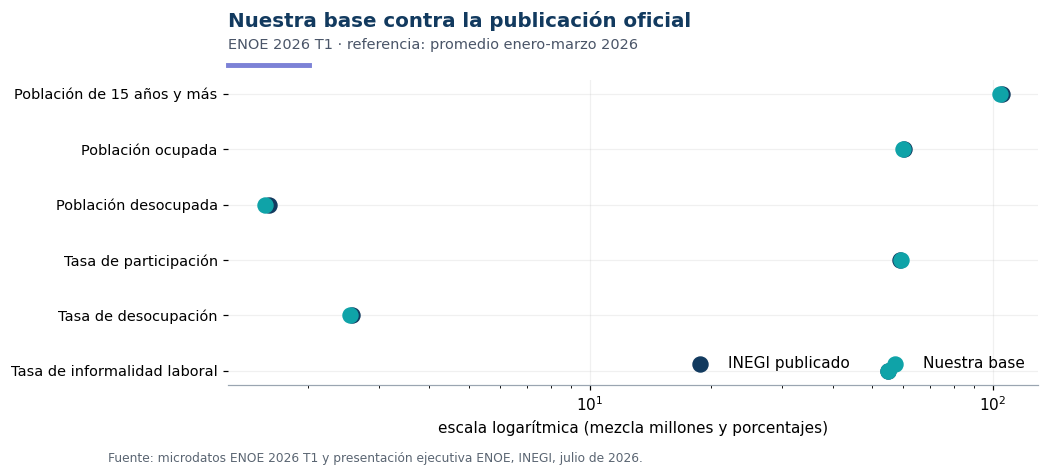

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
et = [k.replace(" (millones)", "").replace(" (%)", "") for k in val.index]
y = np.arange(len(val))
ax.hlines(y, val["INEGI publicado"], val["Nuestra base"], color=CL["gray"], lw=2.5, zorder=1)
ax.scatter(val["INEGI publicado"], y, s=95, color=CL["navy"], zorder=3, label="INEGI publicado")
ax.scatter(val["Nuestra base"], y, s=95, color=CL["teal"], zorder=3, label="Nuestra base")
ax.set_yticks(y); ax.set_yticklabels(et, fontsize=9.5)
ax.invert_yaxis(); ax.legend(frameon=False, ncol=2, loc="lower right")
ax.set_xscale("log"); ax.set_xlabel("escala logarítmica (mezcla millones y porcentajes)")
titulo(ax, "Nuestra base contra la publicación oficial",
       "ENOE 2026 T1 · referencia: promedio enero-marzo 2026")
nota(fig, "Fuente: microdatos ENOE 2026 T1 y presentación ejecutiva ENOE, INEGI, julio de 2026.")
guardar(fig, "01_validacion"); plt.show()

peor = val["Dif. relativa"].str.rstrip(" %").astype(float).abs().max()
caja("insight", f"Todos los indicadores caen dentro de <b>{peor:.1f}%</b> de la cifra oficial. "
     "La unión de las cinco tablas, el filtro de entrevistas completas y el factor de expansión "
     "están bien aplicados. La base se puede usar.")

## 2. Así se ve el ingreso en México según la ENOE

El INEGI no publica un ingreso promedio: publica la distribución en múltiplos del salario
mínimo. Vale la pena verla antes que cualquier promedio, porque explica por qué un modelo de
punto es difícil aquí.

,Nivel de ingreso,Nuestra base (T1 2026) %,INEGI (junio 2026) %
0,Hasta 1 SM,46.9,45.6
1,Más de 1 a 2 SM,30.7,31.9
2,Más de 2 a 3 SM,6.1,5.8
3,Más de 3 a 5 SM,2.4,2.4
4,Más de 5 SM,0.8,0.8
5,No recibe ingresos,4.5,4.5
6,No especificado,8.7,9.1


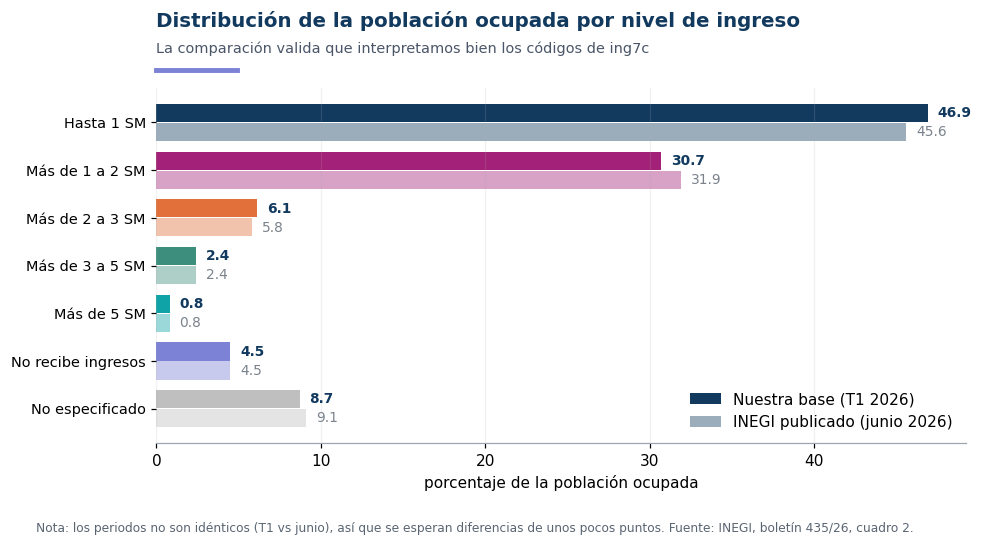

In [6]:
# ing7c: nivel de ingreso en rangos de salarios mínimos.
ETIQ_ING7 = {1: "Hasta 1 SM", 2: "Más de 1 a 2 SM", 3: "Más de 2 a 3 SM",
             4: "Más de 3 a 5 SM", 5: "Más de 5 SM",
             6: "No recibe ingresos", 7: "No especificado"}
# Distribución publicada por INEGI para junio de 2026 (Cuadro 2 del boletín).
INEGI_JUN = {1: 45.6, 2: 31.9, 3: 5.8, 4: 2.4, 5: 0.8, 6: 4.5, 7: 9.1}

dist = pd.DataFrame([{
    "Nivel de ingreso": ETIQ_ING7[k],
    "Nuestra base (T1 2026) %": 100 * share(OCU & ING7.eq(k), OCU),
    "INEGI (junio 2026) %": INEGI_JUN[k],
} for k in ETIQ_ING7]).round(1)
display(dist)

cat = list(ETIQ_ING7.values()); y = np.arange(len(cat))
fig, ax = plt.subplots(figsize=(9.5, 4.2))
cols = [CL["navy"], CL["magenta"], CL["orange"], CL["green"], CL["teal"], CL["lila"], CL["gray"]]
ax.barh(y - .2, dist["Nuestra base (T1 2026) %"], .38, color=cols, label="Nuestra base (T1 2026)")
ax.barh(y + .2, dist["INEGI (junio 2026) %"], .38, color=cols, alpha=.42,
        label="INEGI publicado (junio 2026)")
for i, (a, b) in enumerate(zip(dist["Nuestra base (T1 2026) %"], dist["INEGI (junio 2026) %"])):
    ax.text(a + .6, i - .2, f"{a:.1f}", va="center", fontsize=9, fontweight="bold", color=CL["navy"])
    ax.text(b + .6, i + .2, f"{b:.1f}", va="center", fontsize=9, color="#7A828C")
ax.set_yticks(y); ax.set_yticklabels(cat, fontsize=9.5); ax.invert_yaxis()
ax.set_xlabel("porcentaje de la población ocupada"); ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", alpha=0)
titulo(ax, "Distribución de la población ocupada por nivel de ingreso",
       "La comparación valida que interpretamos bien los códigos de ing7c")
nota(fig, "Nota: los periodos no son idénticos (T1 vs junio), así que se esperan diferencias de "
          "unos pocos puntos. Fuente: INEGI, boletín 435/26, cuadro 2.")
guardar(fig, "02_distribucion_ingreso"); plt.show()

bajo2 = dist.iloc[0:2]["Nuestra base (T1 2026) %"].sum()
caja("insight", f"<b>{bajo2:.0f}% de las personas ocupadas gana hasta 2 salarios mínimos.</b> "
     "La distribución del ingreso en México está fuertemente comprimida en el extremo bajo y "
     "tiene una cola larga muy delgada. Para el modelo eso significa que el poder discriminante "
     "útil está concentrado en un rango estrecho de pesos: distinguir entre 8 mil y 12 mil "
     "importa mucho más que acertar en los casos de 80 mil.")

## 3. El hallazgo principal: el ingreso falta más de lo que parece

Aquí es donde el boletín del INEGI nos da una pista valiosa. El INEGI reporta que el ingreso
"no especificado" fue **9.1%** de los ocupados en junio de 2026. Nuestra base tiene alrededor
del 30% de ocupados sin un monto en pesos.

Esa brecha no es un error de nuestra base. Es que el INEGI, para clasificar a alguien en un
nivel de ingreso, **usa también la pregunta de rango** (en cuántos salarios mínimos cae) cuando
la persona no da un monto exacto. Nosotros solo estábamos usando el monto.

,Grupo,Personas (muestra),Población,% de ocupados,Horas medianas
0,Declaró un monto en pesos,126226,"40,166,074",67.1,43.0
1,No recibe ingresos (trabajo familiar),7488,"2,669,537",4.5,30.0
2,"Sin monto, pero dio el rango en SM",54381,"16,916,457",28.2,44.0
3,Sin monto y sin rango,509,"141,232",0.2,0.0


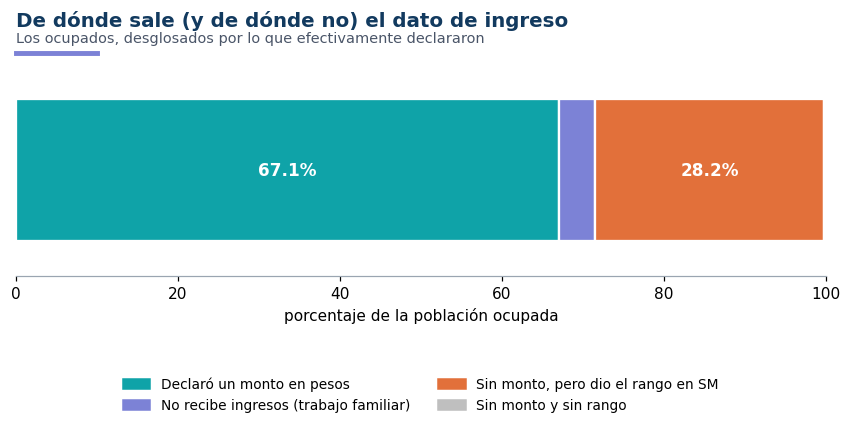

In [7]:
p6c = df["c2_p6c"].astype("string").str.strip() if "c2_p6c" in df.columns else pd.Series(pd.NA, index=df.index)
tiene_rango = p6c.notna() & p6c.ne("") & p6c.ne("0")

g_monto  = OCU & (ING > 0)
g_sinpag = OCU & (ING == 0) & (POS_OCU.eq(4) | ING7.eq(6))
g_rango  = OCU & (ING == 0) & ~g_sinpag & (tiene_rango | ING7.between(1, 5))
g_nada   = OCU & (ING == 0) & ~g_sinpag & ~g_rango

grupos = [("Declaró un monto en pesos", g_monto, CL["teal"]),
          ("No recibe ingresos (trabajo familiar)", g_sinpag, CL["lila"]),
          ("Sin monto, pero dio el rango en SM", g_rango, CL["orange"]),
          ("Sin monto y sin rango", g_nada, CL["gray"])]

tab = pd.DataFrame([{"Grupo": n, "Personas (muestra)": int(m.sum()),
                     "Población": pobl(m), "% de ocupados": 100 * share(m, OCU),
                     "Horas medianas": w_quantile(num("hrsocup").where(m))} for n, m, _ in grupos])
tab["Población"] = tab["Población"].map("{:,.0f}".format)
display(tab.round(1))

fig, ax = plt.subplots(figsize=(9.5, 2.5))
izq = 0
for n, m, c in grupos:
    v = 100 * share(m, OCU)
    ax.barh(0, v, left=izq, color=c, edgecolor="white", lw=1.5)
    if v > 8:
        ax.text(izq + v / 2, 0, f"{v:.1f}%", ha="center", va="center",
                color="white", fontweight="bold", fontsize=11)
    izq += v
ax.set_xlim(0, 100); ax.set_ylim(-.6, .6); ax.set_yticks([]); ax.grid(alpha=0)
ax.set_xlabel("porcentaje de la población ocupada")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for _, _, c in grupos],
          [n for n, _, _ in grupos], frameon=False, ncol=2,
          loc="upper center", bbox_to_anchor=(.5, -.42), fontsize=9)
titulo(ax, "De dónde sale (y de dónde no) el dato de ingreso",
       "Los ocupados, desglosados por lo que efectivamente declararon")
guardar(fig, "03_cobertura_ingreso"); plt.show()

rec = 100 * share(g_rango, OCU)
irr = 100 * share(g_nada, OCU)
caja("insight",
     f"El <b>{rec:.0f}% de los ocupados no dio un monto pero sí dijo en qué rango de salarios "
     f"mínimos cae</b>. Esa información es recuperable y hoy la estamos tirando. "
     f"Lo verdaderamente irrecuperable es apenas el <b>{irr:.0f}%</b>, que es del orden del "
     "9.1% que reporta el INEGI como no especificado.")

caja("accion",
     "Entrenar solo con quienes declararon monto significa descartar a uno de cada tres "
     "trabajadores. La primera decisión del proyecto es <b>usar el rango como información "
     "parcial</b> en vez de tratarlo como dato faltante — el mismo principio que ya aplicamos "
     "en inferencia de rechazados del lado crediticio.")

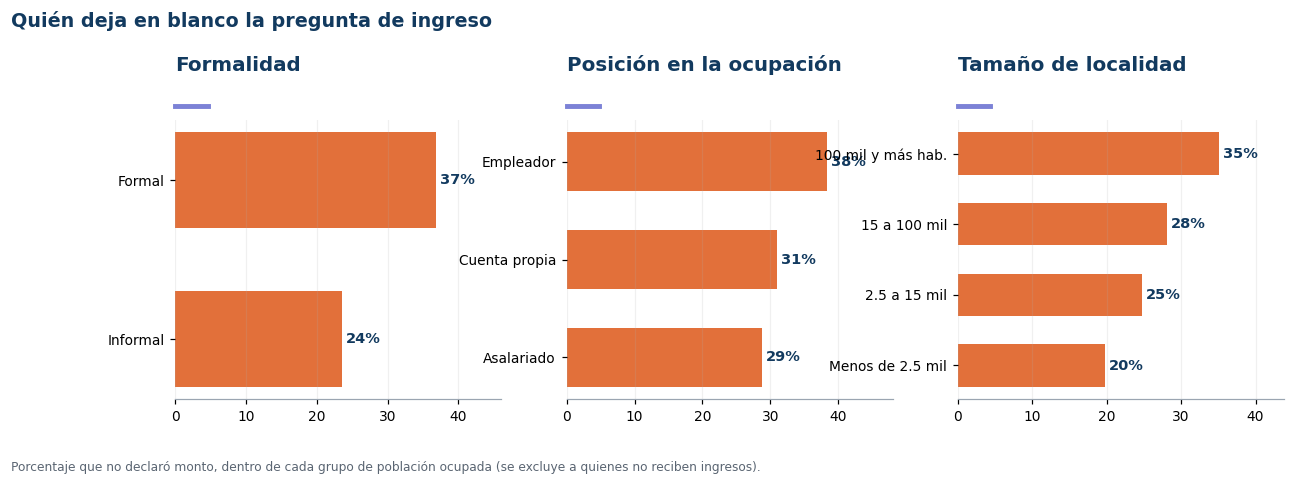

In [8]:
# ¿Quién es el que no contesta?
elegible = OCU & ~g_sinpag
no_resp  = elegible & (ING == 0)

MAPAS = {"emp_ppal": ({"1": "Informal", "2": "Formal"}, "Formalidad"),
         "pos_ocu":  ({"1": "Asalariado", "2": "Empleador", "3": "Cuenta propia"},
                      "Posición en la ocupación"),
         "t_loc_tri":({"1": "100 mil y más hab.", "2": "15 a 100 mil", "3": "2.5 a 15 mil",
                       "4": "Menos de 2.5 mil"}, "Tamaño de localidad")}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, (v, (mapa, et)) in zip(axes, MAPAS.items()):
    s = df[v].astype(str)
    filas = [(mapa.get(k, k), 100 * share(no_resp, elegible & s.eq(k)))
             for k in mapa if (elegible & s.eq(k)).sum() > 100]
    filas.sort(key=lambda r: r[1])
    ax.barh([f[0] for f in filas], [f[1] for f in filas], color=CL["orange"], height=.6)
    for i, (_, val_) in enumerate(filas):
        ax.text(val_ + .6, i, f"{val_:.0f}%", va="center", fontsize=9.5,
                fontweight="bold", color=CL["navy"])
    ax.set_xlim(0, max([f[1] for f in filas]) * 1.25); ax.grid(axis="y", alpha=0)
    titulo(ax, et)
    ax.tick_params(labelsize=9)
fig.suptitle("Quién deja en blanco la pregunta de ingreso", x=.01, ha="left",
             fontsize=12.5, fontweight="bold", color=CL["navy"], y=1.18)
nota(fig, "Porcentaje que no declaró monto, dentro de cada grupo de población ocupada "
          "(se excluye a quienes no reciben ingresos).")
guardar(fig, "04_quien_no_contesta"); plt.show()

nr_f = 100 * share(no_resp, elegible & num("emp_ppal").eq(2))
nr_i = 100 * share(no_resp, elegible & num("emp_ppal").eq(1))
caja("alerta",
     f"La no respuesta no es pareja: <b>{nr_i:.0f}% entre informales contra {nr_f:.0f}% entre "
     "formales</b>. Justo la población que nos interesa para el segmento sin historial "
     "crediticio es la que menos contesta. Si ignoramos esto, el modelo aprende sobre una "
     "muestra desviada hacia el empleo formal y luego lo aplicamos a quien no se parece a ella.")

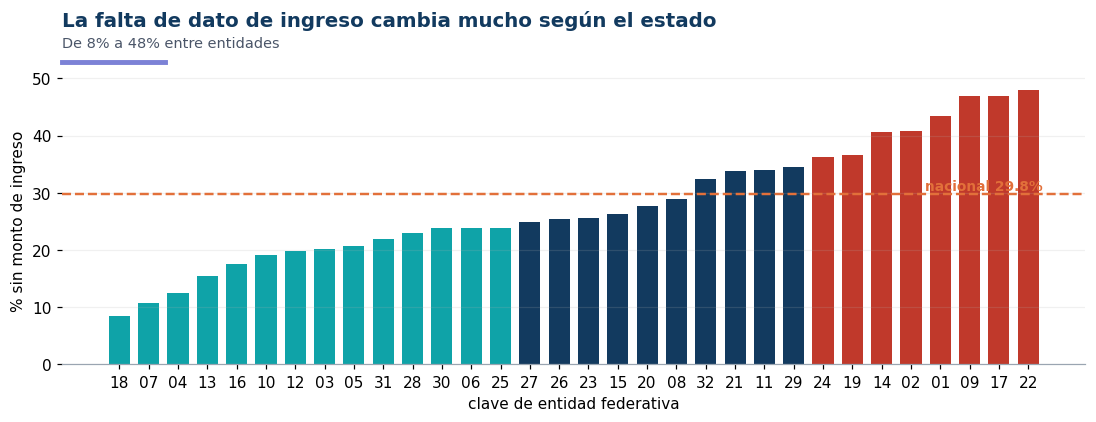

In [9]:
# Dispersión geográfica
ent = df["cve_ent"].astype(str)
por_ent = pd.DataFrame([{"ent": e, "nr": 100 * share(no_resp, elegible & ent.eq(e))}
                        for e in sorted(ent.unique())]).sort_values("nr")
nac = 100 * share(no_resp, elegible)

fig, ax = plt.subplots(figsize=(12, 3.4))
colores = [CL["rojo"] if v > nac + 5 else CL["teal"] if v < nac - 5 else CL["navy"]
           for v in por_ent["nr"]]
ax.bar(por_ent["ent"], por_ent["nr"], color=colores, width=.72)
ax.axhline(nac, color=CL["orange"], ls="--", lw=1.6)
ax.text(len(por_ent) - .5, nac + .6, f"nacional {nac:.1f}%", ha="right",
        fontsize=9, color=CL["orange"], fontweight="bold")
ax.set_ylabel("% sin monto de ingreso"); ax.set_xlabel("clave de entidad federativa")
ax.grid(axis="x", alpha=0)
titulo(ax, "La falta de dato de ingreso cambia mucho según el estado",
       f"De {por_ent['nr'].min():.0f}% a {por_ent['nr'].max():.0f}% entre entidades")
guardar(fig, "05_no_respuesta_estado"); plt.show()

caja("alerta",
     "Este es el punto más delicado para el enriquecimiento geográfico. Si calculamos "
     "el ingreso mediano de cada municipio usando solo a quienes contestaron, en unos "
     "municipios ese promedio se construye con el 75% de la gente y en otros con el 55%, "
     "y esa diferencia está correlacionada con la informalidad. <b>El feature geográfico "
     "quedaría sesgado de forma desigual entre territorios</b>, no con un error parejo que "
     "se cancele.")

## 4. ¿Qué tanto podemos predecir con lo que sí tenemos de un solicitante?

Pregunta de producto: la ENOE tiene 523 columnas, pero al puntuar a una persona solo sabemos
lo que viene en su solicitud. Este ejercicio agrega bloques de variables en orden de
disponibilidad real y mide cuánto sube la capacidad de predicción.

In [10]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score

BLOQUES = {
    "Lo básico\n(edad, sexo,\nestado)":      ["eda", "sex", "cve_ent", "t_loc_tri"],
    "+ Contexto\ngeográfico":                ["mun_ing_mediana_shrunk", "ent_ing_mediana_ocup",
                                              "mun_tasa_informalidad", "mun_n_muestra",
                                              "ent_esc_media"],
    "+ Lo declarado\nen solicitud":          ["anios_esc", "niv_ins", "e_con", "n_hij"],
    "+ Situación laboral\n(NO disponible)":  ["pos_ocu", "emp_ppal", "seg_soc", "rama_est2",
                                              "scian", "tue_ppal", "hrsocup"],
}

modelo = OCU & (ING > 0) & EDAD.between(18, 80)
d = df.loc[modelo].copy()
y = np.log(pd.to_numeric(d["ingocup"], errors="coerce"))
sw = pd.to_numeric(d[FAC], errors="coerce")
grupos = d["upm"].astype(str) if "upm" in d.columns else d["cvegeo"].astype(str)
print(f"Muestra: {len(d):,} personas con ingreso declarado, {grupos.nunique():,} conglomerados")

def preparar(cols):
    X = pd.DataFrame(index=d.index)
    for c in cols:
        if c not in d.columns: continue
        s = pd.to_numeric(d[c], errors="coerce")
        X[c] = s if s.notna().mean() > .5 else d[c].astype("category").cat.codes
    return X

acum, res = [], []
for nombre, cols in BLOQUES.items():
    acum += cols
    X = preparar(acum)
    if X.empty: continue
    oof = pd.Series(np.nan, index=d.index)
    for tr, te in GroupKFold(n_splits=3).split(X, y, groups=grupos):
        m = HistGradientBoostingRegressor(max_iter=200, learning_rate=.08,
                                          max_depth=6, random_state=0)
        m.fit(X.iloc[tr], y.iloc[tr], sample_weight=sw.iloc[tr])
        oof.iloc[te] = m.predict(X.iloc[te])
    res.append({"bloque": nombre, "vars": X.shape[1],
                "R2": r2_score(y, oof, sample_weight=sw),
                "acierto_20": 100 * float(np.average(
                    (np.abs(np.exp(oof) / np.exp(y) - 1) <= .20).astype(float), weights=sw))})
    print(f"  ✓ {nombre.replace(chr(10),' ')}  R²={res[-1]['R2']:.3f}")
res = pd.DataFrame(res)
res["aporte"] = res["R2"].diff().fillna(res["R2"])

Muestra: 122,911 personas con ingreso declarado, 20,083 conglomerados
  ✓ Lo básico (edad, sexo, estado)  R²=0.233
  ✓ + Contexto geográfico  R²=0.269
  ✓ + Lo declarado en solicitud  R²=0.348
  ✓ + Situación laboral (NO disponible)  R²=0.571


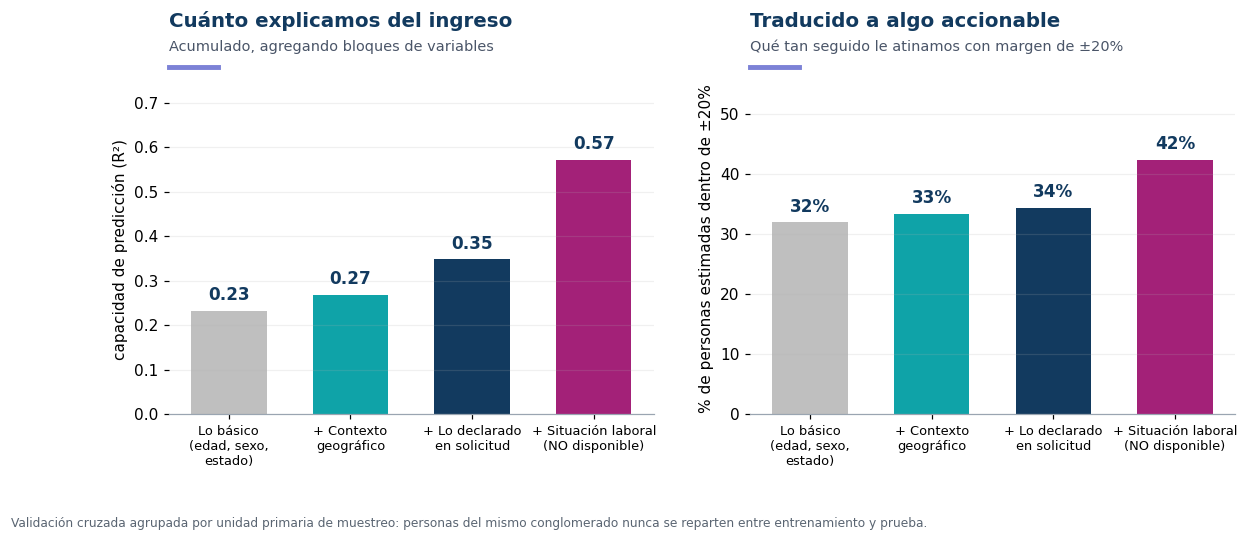

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.9))
cols4 = [CL["gray"], CL["teal"], CL["navy"], CL["magenta"]][:len(res)]

ax[0].bar(range(len(res)), res["R2"], color=cols4, width=.62)
for i, v in enumerate(res["R2"]):
    etiqueta_barra(ax[0], i, v, f"{v:.2f}")
ax[0].set_xticks(range(len(res))); ax[0].set_xticklabels(res["bloque"], fontsize=8.5)
ax[0].set_ylabel("capacidad de predicción (R²)"); ax[0].grid(axis="x", alpha=0)
ax[0].set_ylim(0, max(res["R2"]) * 1.3)
titulo(ax[0], "Cuánto explicamos del ingreso", "Acumulado, agregando bloques de variables")

ax[1].bar(range(len(res)), res["acierto_20"], color=cols4, width=.62)
for i, v in enumerate(res["acierto_20"]):
    etiqueta_barra(ax[1], i, v, f"{v:.0f}%")
ax[1].set_xticks(range(len(res))); ax[1].set_xticklabels(res["bloque"], fontsize=8.5)
ax[1].set_ylabel("% de personas estimadas dentro de ±20%"); ax[1].grid(axis="x", alpha=0)
ax[1].set_ylim(0, max(res["acierto_20"]) * 1.3)
titulo(ax[1], "Traducido a algo accionable", "Qué tan seguido le atinamos con margen de ±20%")
nota(fig, "Validación cruzada agrupada por unidad primaria de muestreo: personas del mismo "
          "conglomerado nunca se reparten entre entrenamiento y prueba.", y=-0.13)
guardar(fig, "06_valor_features"); plt.show()

disp = res.iloc[min(2, len(res)-1)]
full = res.iloc[-1]
geo_ap = res.iloc[1]["aporte"] if len(res) > 1 else np.nan
caja("insight",
     f"Con lo que realmente sabemos de un solicitante llegamos a un R² de "
     f"<b>{disp['R2']:.2f}</b> y acertamos dentro de ±20% en el <b>{disp['acierto_20']:.0f}%</b> "
     f"de los casos. Conocer la situación laboral lo subiría a {full['R2']:.2f}: esa brecha es "
     "el precio de no saber en qué trabaja la persona.")

caja("accion",
     f"El contexto geográfico aporta <b>{geo_ap:+.3f}</b> de R² sobre lo básico. "
     "Ese número es el que hay que poner frente al costo de construir y mantener el pipeline "
     "de enriquecimiento. No es una decisión técnica sino de portafolio: si el aporte es chico, "
     "el mismo esfuerzo puesto en capturar escolaridad en el formulario rinde más.")

## 5. ¿Cuánto del ingreso explica el domicilio?

Pregunta directa para el enriquecimiento geográfico: de toda la variación de ingresos entre
personas, ¿qué parte se explica por dónde viven y qué parte por diferencias entre personas
que viven en el mismo lugar?

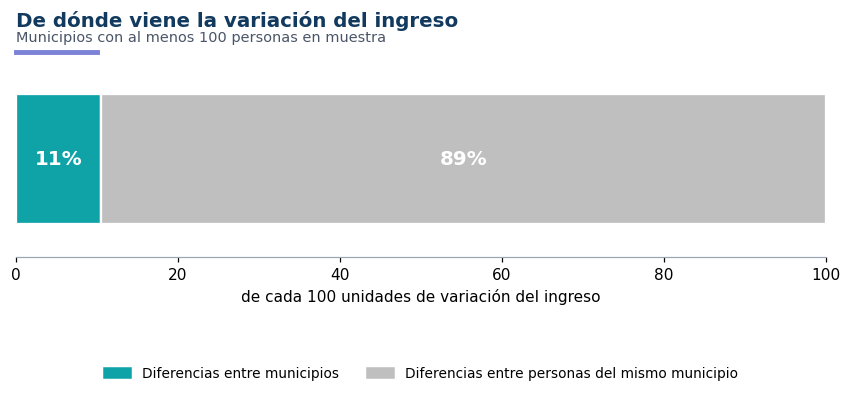

In [12]:
log_ing = np.log(ING_POS.where(modelo))
val_m = log_ing.notna() & W.notna()

def icc(nivel, mask=None):
    m = val_m if mask is None else mask
    g = df.loc[m, nivel].astype(str); yy, ww = log_ing[m], W[m]
    mu = np.average(yy, weights=ww); entre = 0.0
    for _, idx in yy.groupby(g).groups.items():
        entre += ww[idx].sum() * (np.average(yy[idx], weights=ww[idx]) - mu) ** 2
    return (entre / ww.sum()) / np.average((yy - mu) ** 2, weights=ww)

tam = df.loc[val_m, "cvegeo"].astype(str).value_counts()
grandes = set(tam[tam >= 100].index)
icc_mun = icc("cvegeo", val_m & df["cvegeo"].astype(str).isin(grandes)) if len(grandes) >= 10 \
          else icc("cvegeo")
icc_ent = icc("cve_ent")

fig, ax = plt.subplots(figsize=(9.5, 2.3))
piezas = [("Diferencias entre municipios", 100 * icc_mun, CL["teal"]),
          ("Diferencias entre personas del mismo municipio", 100 * (1 - icc_mun), CL["gray"])]
izq = 0
for n, v, c in piezas:
    ax.barh(0, v, left=izq, color=c, edgecolor="white", lw=1.5)
    ax.text(izq + v / 2, 0, f"{v:.0f}%", ha="center", va="center", color="white",
            fontweight="bold", fontsize=13)
    izq += v
ax.set_xlim(0, 100); ax.set_ylim(-.6, .6); ax.set_yticks([]); ax.grid(alpha=0)
ax.set_xlabel("de cada 100 unidades de variación del ingreso")
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for _, _, c in piezas],
          [n for n, _, _ in piezas], frameon=False, ncol=2,
          loc="upper center", bbox_to_anchor=(.5, -.5), fontsize=9)
titulo(ax, "De dónde viene la variación del ingreso",
       "Municipios con al menos 100 personas en muestra")
guardar(fig, "07_geografia"); plt.show()

MUN_MX = 2475
cub = df["cvegeo"].astype(str).nunique()
kpis([("Explicado por el municipio", "de la variación total", f"{100*icc_mun:.0f} %"),
      ("Explicado por el estado", "de la variación total", f"{100*icc_ent:.0f} %"),
      ("Municipios con datos", f"de ~{MUN_MX:,} en el país", f"{cub:,}"),
      ("Cobertura territorial", "municipios del país", f"{100*cub/MUN_MX:.0f} %")])

caja("insight",
     f"Saber el municipio explica alrededor del <b>{100*icc_mun:.0f}%</b> de la variación del "
     "ingreso. El resto son diferencias entre vecinos: dos personas de la misma colonia pueden "
     "ganar muy distinto. El dato geográfico sirve para mover el punto de partida de la "
     "estimación, no para distinguir entre solicitantes de un mismo municipio.")

caja("alerta",
     f"Además, la ENOE solo toca <b>{cub:,} de los ~{MUN_MX:,} municipios</b> del país. "
     "Los que faltan son los rurales y pequeños, donde vive buena parte de la población sin "
     "historial crediticio. Ahí el feature llegaría vacío y habría que sustituirlo por el "
     "promedio estatal, que es exactamente perder la variación que queríamos capturar.")

## 6. El segmento informal: nuestro mejor espejo del solicitante sin historial

Nadie está marcado como "sin historial crediticio" en la ENOE, pero la informalidad es el
proxy más cercano: empleo sin seguridad social ni reconocimiento de la relación laboral.
Según el INEGI son 33.1 millones de personas, el 55% de los ocupados.

,Segmento,Ingreso mediano,P10,P90,Escolaridad media,No declaró ingreso (%)
0,Formal,12000.0,7740.0,24000.0,12.3,36.9
1,Informal,7525.0,2150.0,15000.0,9.1,23.5


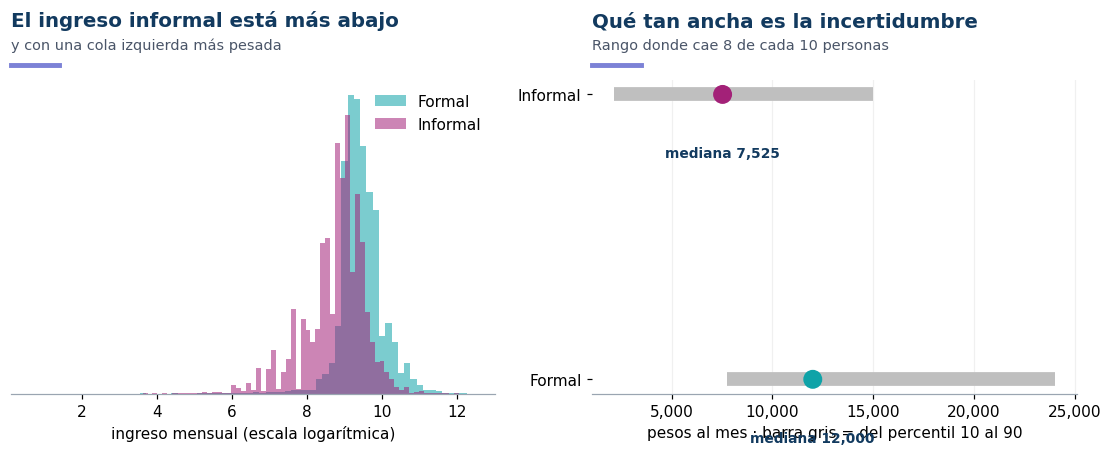

In [13]:
formal   = OCU & num("emp_ppal").eq(2) & (ING > 0)
informal_i = OCU & num("emp_ppal").eq(1) & (ING > 0)

perf = pd.DataFrame([{
    "Segmento": n,
    "Ingreso mediano": w_quantile(ING_POS.where(m)),
    "P10": w_quantile(ING_POS.where(m), .10),
    "P90": w_quantile(ING_POS.where(m), .90),
    "Escolaridad media": w_mean(num("anios_esc").where(m).where(lambda s: s < 99)),
    "No declaró ingreso (%)": 100 * share(no_resp, elegible & num("emp_ppal").eq(
        2 if n == "Formal" else 1)),
} for n, m in [("Formal", formal), ("Informal", informal_i)]])
display(perf.round(1))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.7))
for m, n, c in [(formal, "Formal", CL["teal"]), (informal_i, "Informal", CL["magenta"])]:
    xx = np.log(ING_POS.where(m)).dropna()
    ax[0].hist(xx, bins=70, weights=W[xx.index], density=True, alpha=.55, label=n, color=c)
ax[0].set_xlabel("ingreso mensual (escala logarítmica)"); ax[0].set_yticks([])
ax[0].legend(frameon=False); ax[0].grid(alpha=0)
titulo(ax[0], "El ingreso informal está más abajo", "y con una cola izquierda más pesada")

y2 = np.arange(2)
ax[1].hlines(y2, perf["P10"], perf["P90"], color=CL["gray"], lw=9)
ax[1].scatter(perf["Ingreso mediano"], y2, s=130, color=[CL["teal"], CL["magenta"]], zorder=3)
for i, r in perf.iterrows():
    ax[1].text(r["Ingreso mediano"], i - .22, f"mediana {r['Ingreso mediano']:,.0f}",
               ha="center", fontsize=9, fontweight="bold", color=CL["navy"])
ax[1].set_yticks(y2); ax[1].set_yticklabels(perf["Segmento"]); ax[1].grid(axis="y", alpha=0)
ax[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax[1].set_xlabel("pesos al mes · barra gris = del percentil 10 al 90")
titulo(ax[1], "Qué tan ancha es la incertidumbre", "Rango donde cae 8 de cada 10 personas")
guardar(fig, "08_formal_informal"); plt.show()

razon = perf.loc[1, "Ingreso mediano"] / perf.loc[0, "Ingreso mediano"]
sd_f = np.sqrt(w_var(np.log(ING_POS.where(formal))))
sd_i = np.sqrt(w_var(np.log(ING_POS.where(informal_i))))
caja("insight",
     f"El ingreso mediano informal es <b>{razon:.0%}</b> del formal, y su dispersión es "
     f"<b>{sd_i/sd_f:.2f} veces</b> la del formal. Además es el grupo que menos contesta la "
     "pregunta de ingreso. Los tres efectos apuntan en la misma dirección y se acumulan.")

caja("alerta",
     "Consecuencia práctica: un modelo entrenado sobre población mayoritariamente formal no "
     "solo se equivoca en el nivel al aplicarse al segmento informal — se equivoca sobre todo "
     "en <b>qué tan seguro está</b>. Los intervalos de predicción salen demasiado angostos "
     "justo donde más ancho debería ser el margen. Eso se traduce en líneas de crédito mal "
     "dimensionadas, no solo en un score corrido.")

## 7. Conclusiones y decisiones que hay que tomar

Tres decisiones, en orden de urgencia. La primera bloquea a las otras dos.

In [14]:
DEC = [
    ("1. Recuperar el ingreso por rangos",
     "Ciencia de Datos", "Alta", CL["rojo"],
     "Dejar de entrenar solo con quien declaró monto. Usar el rango en salarios mínimos como "
     "información parcial, con imputación múltiple dentro de cada rango. Es lo que ya hace el "
     "INEGI para publicar sus cifras, y explica por qué su 'no especificado' es 9.1% y el "
     "nuestro parece 30%."),
    ("2. Decidir si el enriquecimiento geográfico se queda",
     "Analítica + Producto", "Media", CL["orange"],
     "El aporte del bloque geográfico ya está medido en la sección 4 y su cobertura territorial "
     "en la sección 5. Con esos dos números se puede comparar contra el costo de mantener el "
     "pipeline y contra alternativas como capturar escolaridad en el formulario."),
    ("3. Modelar la incertidumbre, no solo el punto",
     "Ciencia de Datos", "Media", CL["teal"],
     "Dado el amontonamiento del ingreso declarado y la mayor dispersión del segmento informal, "
     "conviene predecir un rango o una distribución en lugar de un número. Encaja mejor con "
     "cómo se toma la decisión de línea de crédito."),
]
filas = "".join(f'''
<tr>
  <td style="padding:11px 13px;border-bottom:1px solid #E5E9ED;font-weight:600;
      color:#123A5F;width:26%">{t}</td>
  <td style="padding:11px 13px;border-bottom:1px solid #E5E9ED;width:13%;font-size:12.5px">{d}</td>
  <td style="padding:11px 13px;border-bottom:1px solid #E5E9ED;width:9%">
      <span style="background:{c};color:white;padding:2px 9px;border-radius:10px;
      font-size:11px;font-weight:600">{p}</span></td>
  <td style="padding:11px 13px;border-bottom:1px solid #E5E9ED;font-size:12.5px;
      line-height:1.5">{x}</td>
</tr>''' for t, d, p, c, x in DEC)
display(HTML(f'''
<table style="border-collapse:collapse;width:100%;font-family:system-ui;margin-top:6px">
<tr style="background:#123A5F;color:white">
  <th style="padding:9px 13px;text-align:left;font-size:12px">Decisión</th>
  <th style="padding:9px 13px;text-align:left;font-size:12px">Dueño sugerido</th>
  <th style="padding:9px 13px;text-align:left;font-size:12px">Prioridad</th>
  <th style="padding:9px 13px;text-align:left;font-size:12px">Detalle</th>
</tr>{filas}</table>'''))

Decisión,Dueño sugerido,Prioridad,Detalle
1. Recuperar el ingreso por rangos,Ciencia de Datos,Alta,"Dejar de entrenar solo con quien declaró monto. Usar el rango en salarios mínimos como información parcial, con imputación múltiple dentro de cada rango. Es lo que ya hace el INEGI para publicar sus cifras, y explica por qué su 'no especificado' es 9.1% y el nuestro parece 30%."
2. Decidir si el enriquecimiento geográfico se queda,Analítica + Producto,Media,El aporte del bloque geográfico ya está medido en la sección 4 y su cobertura territorial en la sección 5. Con esos dos números se puede comparar contra el costo de mantener el pipeline y contra alternativas como capturar escolaridad en el formulario.
"3. Modelar la incertidumbre, no solo el punto",Ciencia de Datos,Media,"Dado el amontonamiento del ingreso declarado y la mayor dispersión del segmento informal, conviene predecir un rango o una distribución en lugar de un número. Encaja mejor con cómo se toma la decisión de línea de crédito."


### Lo que este análisis **no** dice

Para evitar sobrelecturas en la presentación:

- **No dice que la ENOE no sirva.** Dice que la variable de ingreso necesita tratamiento antes
  de usarse, y que el aporte geográfico hay que medirlo contra su costo.
- **No permite unir una persona de la ENOE con un expediente.** La ENOE es anónima por diseño
  muestral. Los usos viables son enriquecimiento por geografía, estimación en dos muestras y
  calibración externa.
- **No es representativa a nivel municipal.** El INEGI diseña la muestra para representar al
  país, a cada estado, a las ciudades autorrepresentadas y por tamaño de localidad. Los
  agregados municipales son indicativos, no inferenciales.
- **Los rangos de salarios mínimos no son comparables entre años** sin ajustar a la base de
  salarios mínimos equivalentes que publica el INEGI. Nuestro T1 2026 usa la base enero 2026.

### Nota metodológica

Todas las cifras están ponderadas por el factor de expansión trimestral (`fac_tri`); un
promedio simple sobre la ENOE no estima nada poblacional. Se aplicó el filtro estándar del
INEGI para tabulados: entrevistas completas y residentes habituales. La validación cruzada de
la sección 4 agrupa por unidad primaria de muestreo.

### Siguiente paso sugerido

Enlazar 2026 T1 con 2026 T2 aprovechando el panel rotatorio: la ENOE visita la misma vivienda
cinco trimestres. Eso permitiría medir **volatilidad del ingreso por persona**, que para riesgo
de crédito suele importar más que el nivel — dos solicitantes con el mismo ingreso promedio y
distinta variabilidad no representan el mismo riesgo.

In [15]:
val.to_csv(OUT / "validacion_vs_inegi.csv")
dist.to_csv(OUT / "distribucion_ingreso.csv", index=False)
tab.to_csv(OUT / "cobertura_ingreso.csv", index=False)
res.to_csv(OUT / "valor_features.csv", index=False)
por_ent.to_csv(OUT / "no_respuesta_por_entidad.csv", index=False)

print("Tablas exportadas a", OUT)
print(f"\n{len(list(FIG.glob('*.png')))} gráficas en {FIG}/ listas para la presentación:")
for p in sorted(FIG.glob("*.png")):
    print("   ", p.name)

Tablas exportadas a salida_analisis

8 gráficas en salida_analisis/figuras/ listas para la presentación:
    01_validacion.png
    02_distribucion_ingreso.png
    03_cobertura_ingreso.png
    04_quien_no_contesta.png
    05_no_respuesta_estado.png
    06_valor_features.png
    07_geografia.png
    08_formal_informal.png
